# 0825_dongjin_022_shap_analysis (Type-Conditioned)

이 노트북은 `0824_kimjaehak_006_type_conditioned_baseline` 모델 결과를 기반으로 각 inspection_type별 XGBoost 모델에 TreeSHAP을 적용하여 해석 가능성을 도출합니다.

In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix

shap.initjs()

DATA_PATH = Path("../data/raw/dataset.csv")
MODEL_PATH = Path("../models/0824_kimjaehak_006_type_conditioned_baseline.pkl")
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"

# 1. 모델 아티팩트 로드
try:
    model_artifact = joblib.load(MODEL_PATH)
    models_by_type = model_artifact["models_by_type"]
    feature_columns_by_type = model_artifact["feature_columns_by_type"]
    decision_threshold = model_artifact["decision_threshold"]
    valid_end_time = pd.to_datetime(model_artifact["validation_end_time"], utc=True)
    print("Model artifact loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    raise


E:\pro_newton\제조 AI\팀 과제\siemens_aoi_ML_practice\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model artifact loaded successfully.


In [2]:
# 2. 데이터 로드 및 전처리 (베이스라인과 동일하게 유지)
print("Loading data...")
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]
if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})

# 중복 제거
dedup_columns = [col for col in raw_df.columns if col not in {RECORD_ID, TIME_COLUMN}]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)

# 시간 정렬
clean_df[TIME_COLUMN] = pd.to_datetime(clean_df[TIME_COLUMN], errors="raise", utc=True)
clean_df = clean_df.sort_values([TIME_COLUMN, RECORD_ID], kind="stable").reset_index(drop=True)

# 테스트 세트 분리
test_mask = clean_df[TIME_COLUMN] > valid_end_time
test_df = clean_df.loc[test_mask].copy()

inspection_types = sorted(test_df[TYPE_COLUMN].unique().tolist())
print(f"Total Test samples: {len(test_df)}")
print(f"Inspection Types in Test: {inspection_types}")


Loading data...


Total Test samples: 78396
Inspection Types in Test: [0, 1, 2, 3, 4]


## 3. Inspection Type별 TreeSHAP 분석

각 inspection type에 해당하는 XGBoost 모델과 Test 세트를 활용해 전역적(Global) 및 국소적(Local) SHAP 분석을 수행합니다.


[ Inspection Type: 0 ]
- Test Samples: 16784
- Positive Samples: 133



>>> Global Summary Plot (Bar) for Type 0


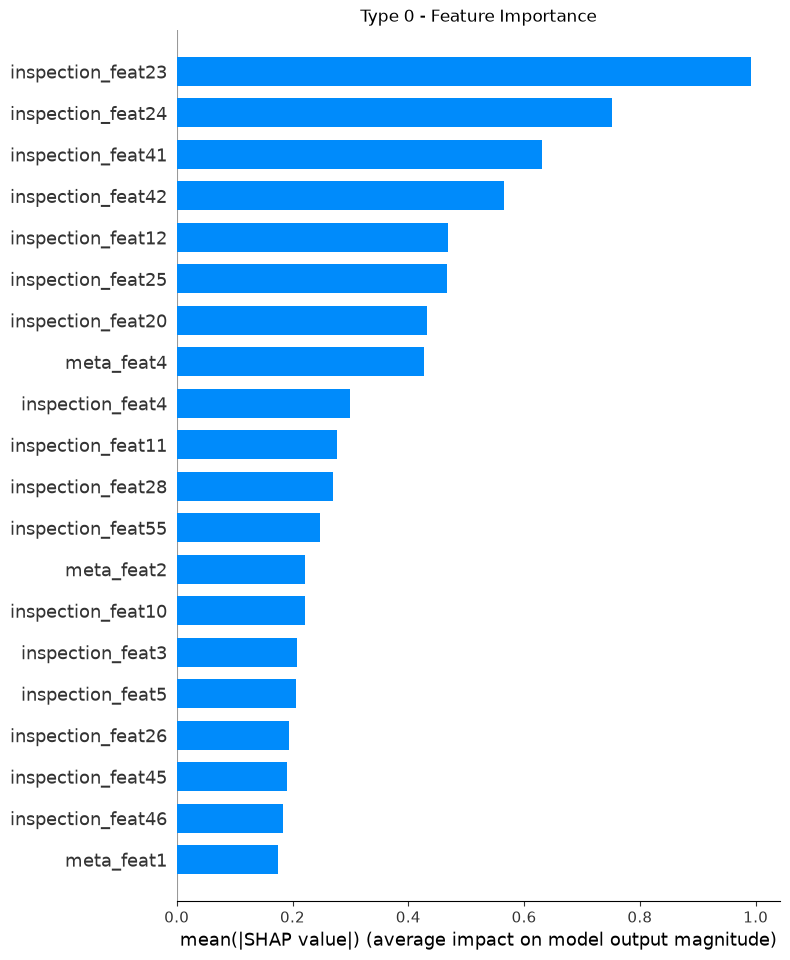


>>> Global Summary Plot (Beeswarm) for Type 0


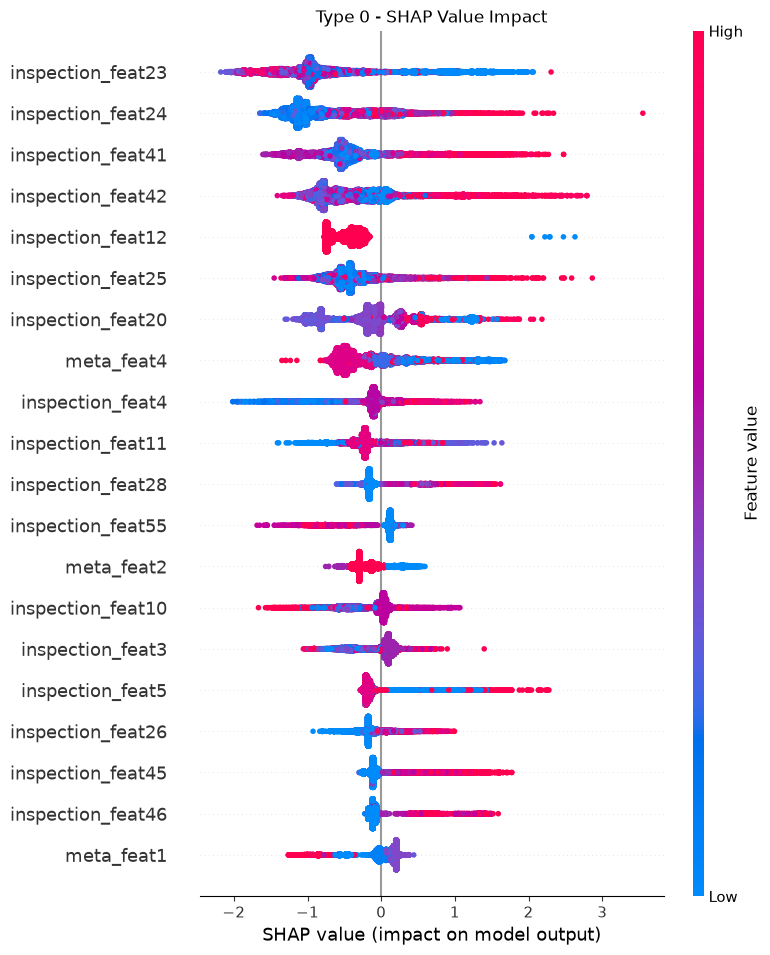


>>> Local Waterfall Plot for True Positive (Index 13653, Prob: 0.5482)


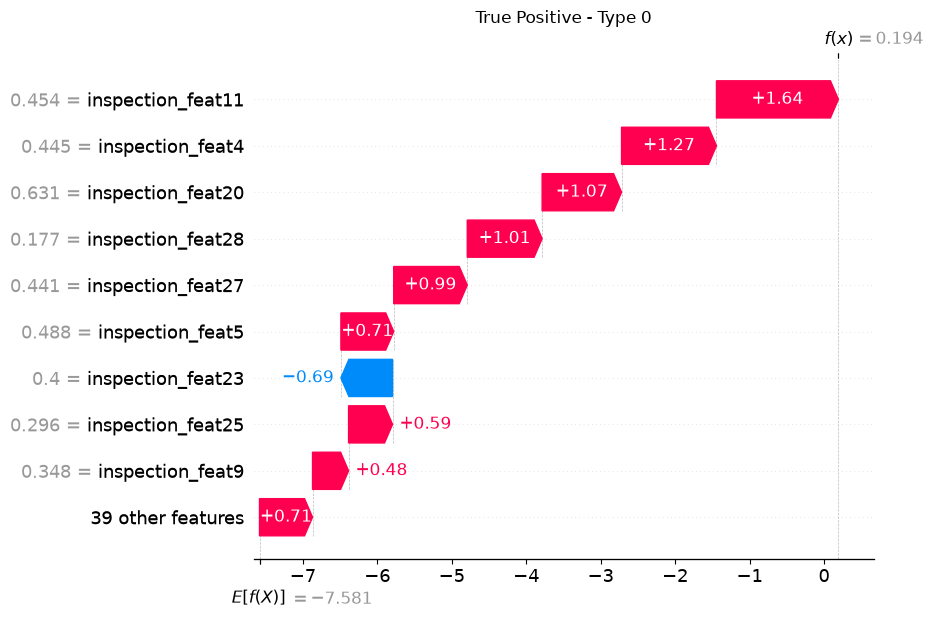


>>> Local Waterfall Plot for False Negative (Index 16080, Prob: 0.0000)


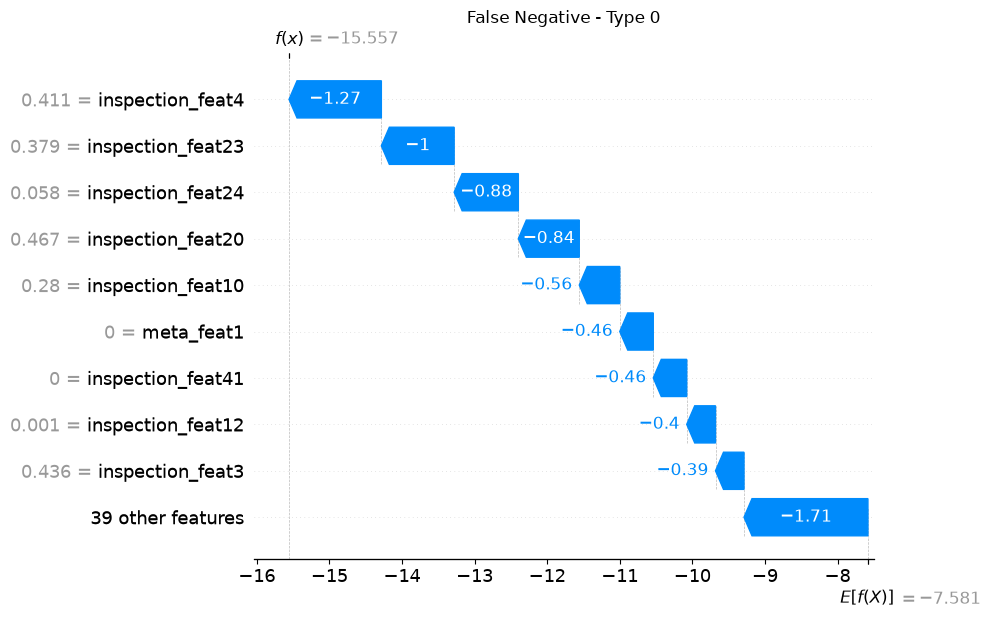


[ Inspection Type: 1 ]
- Test Samples: 11112
- Positive Samples: 784



>>> Global Summary Plot (Bar) for Type 1


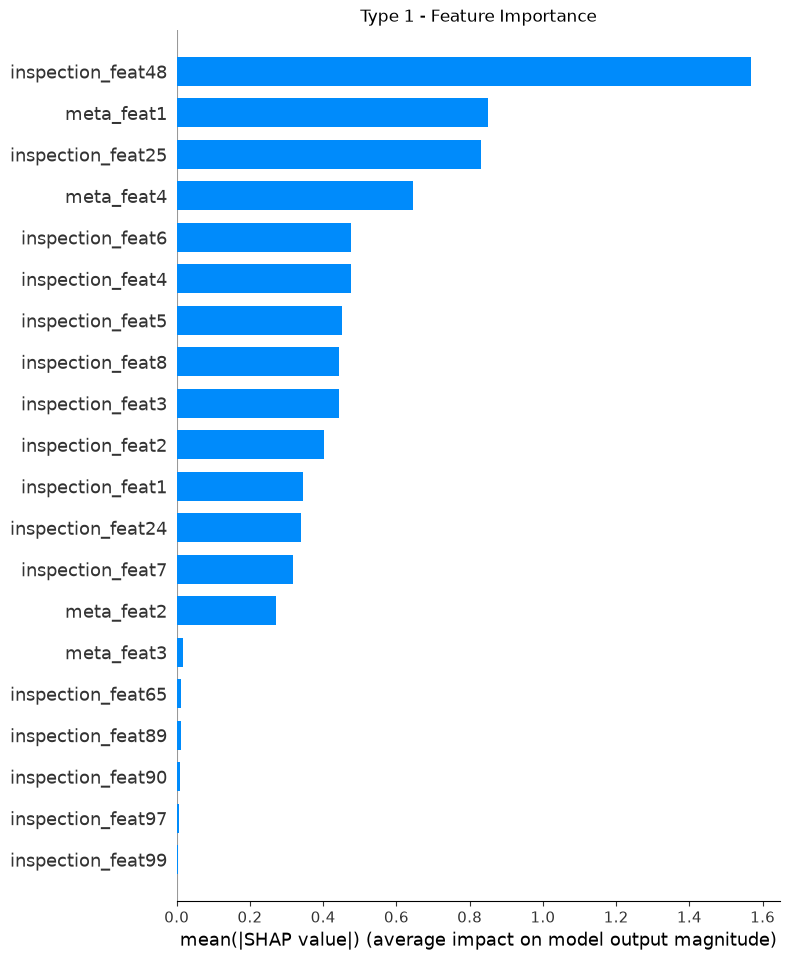


>>> Global Summary Plot (Beeswarm) for Type 1


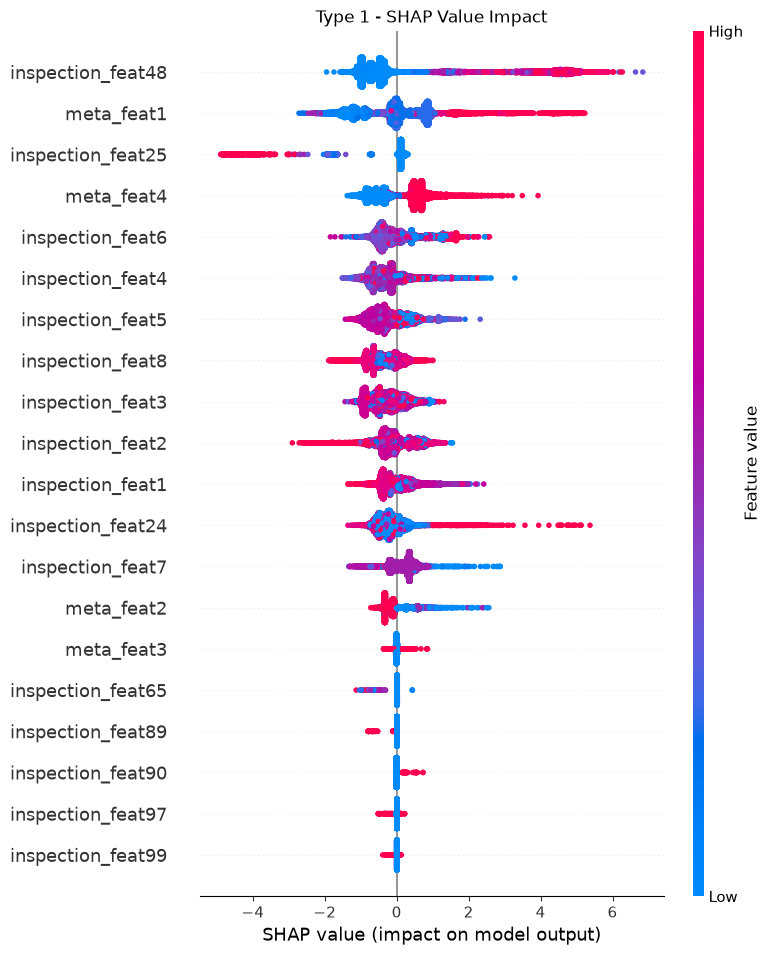


>>> Local Waterfall Plot for True Positive (Index 9255, Prob: 0.9996)


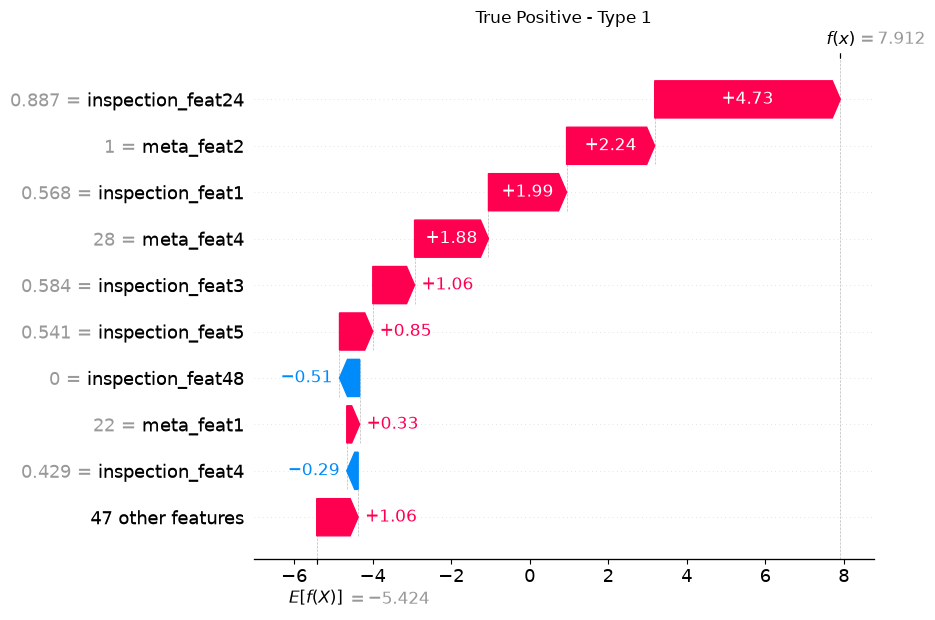


>>> Local Waterfall Plot for False Negative (Index 10889, Prob: 0.0000)


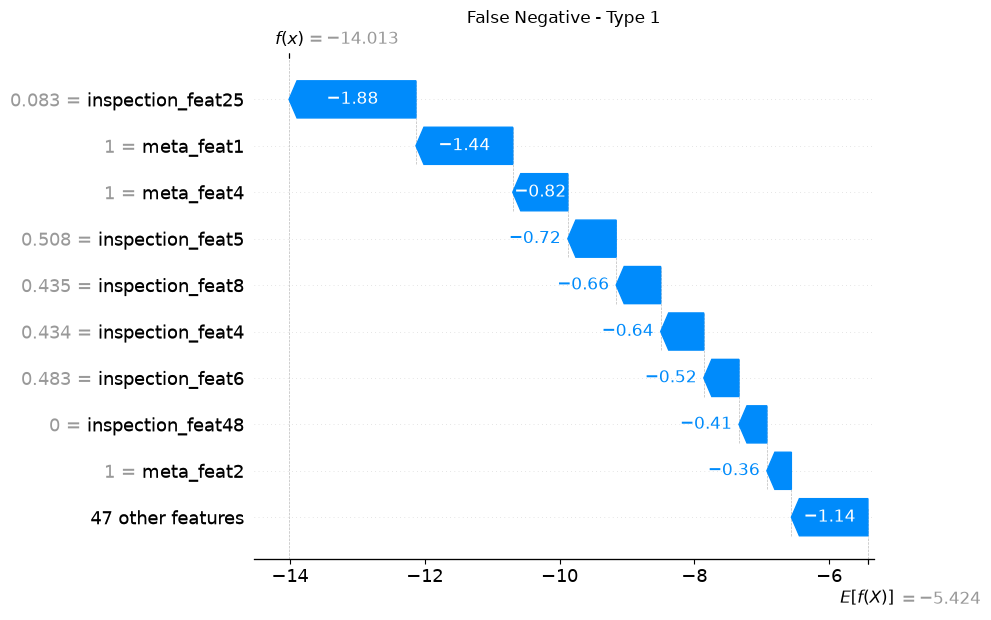


>>> Local Waterfall Plot for False Positive (Index 3904, Prob: 0.9936)


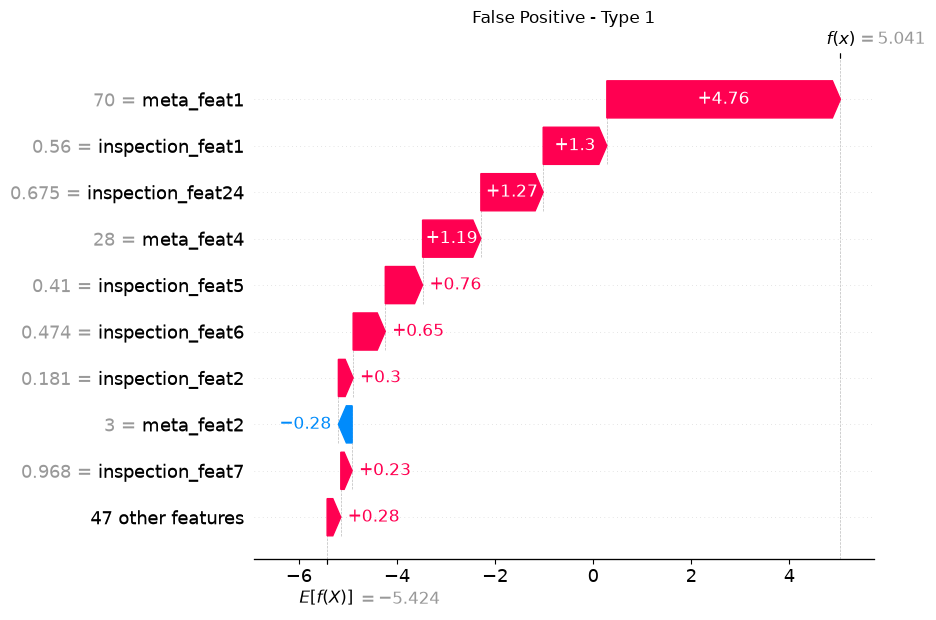


[ Inspection Type: 2 ]
- Test Samples: 19153
- Positive Samples: 703



>>> Global Summary Plot (Bar) for Type 2


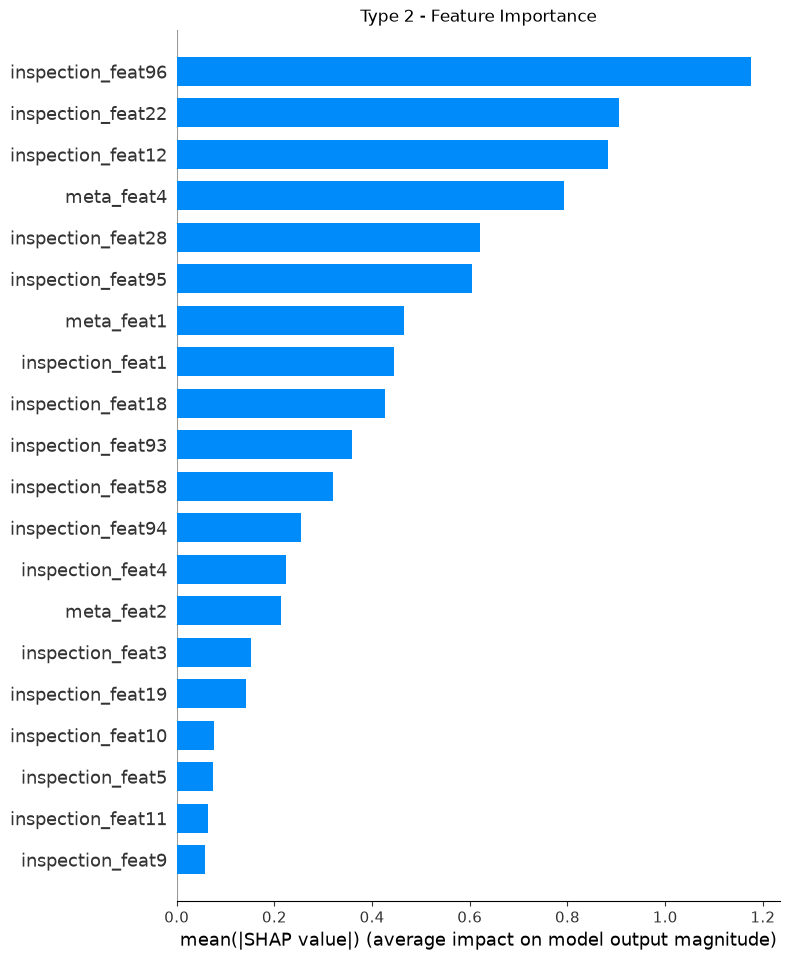


>>> Global Summary Plot (Beeswarm) for Type 2


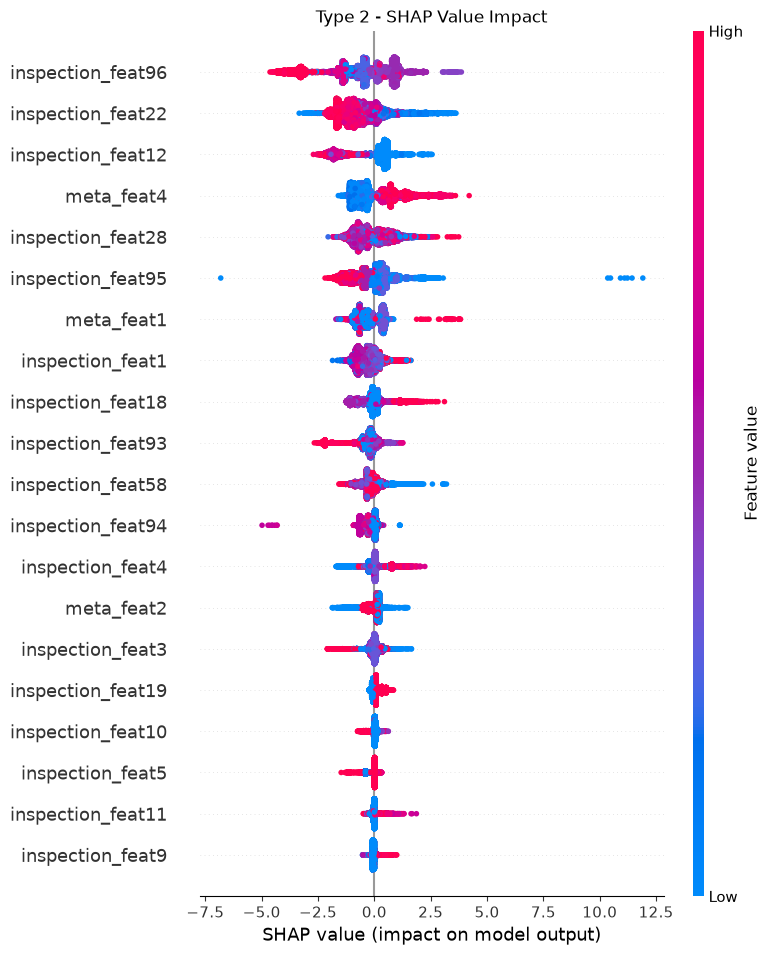


>>> Local Waterfall Plot for True Positive (Index 13747, Prob: 0.9989)


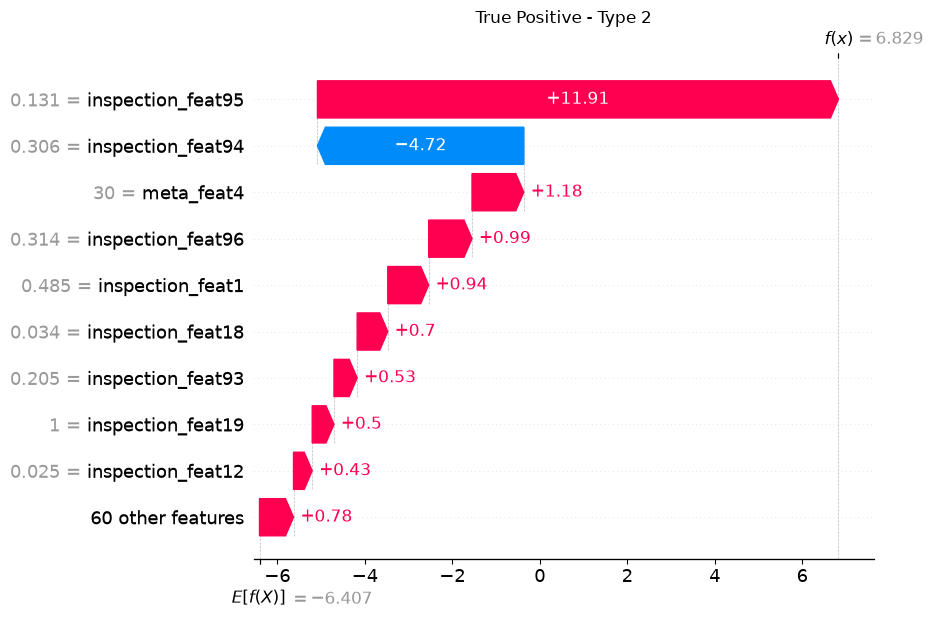


>>> Local Waterfall Plot for False Negative (Index 16567, Prob: 0.0000)


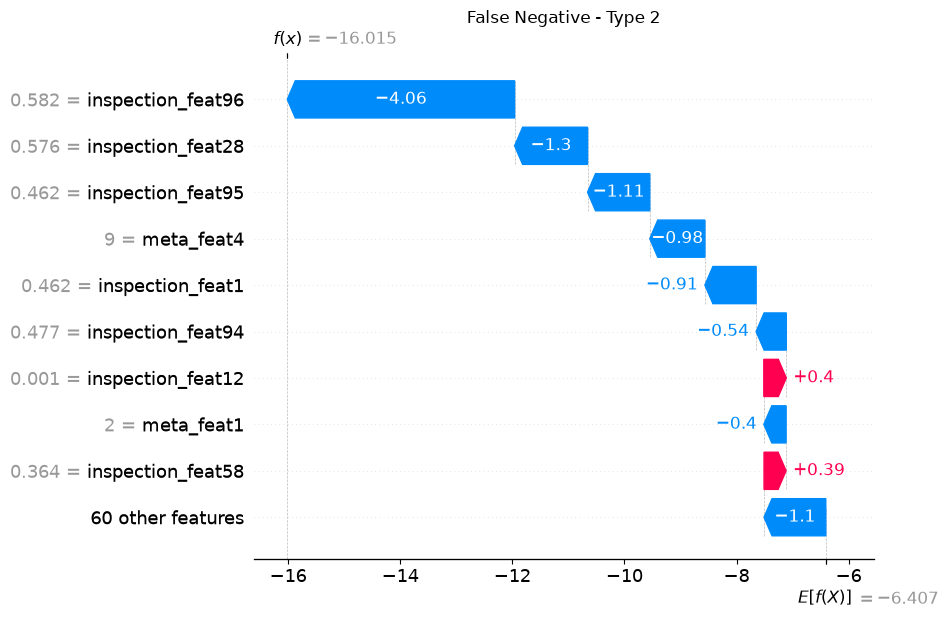


>>> Local Waterfall Plot for False Positive (Index 3878, Prob: 0.9881)


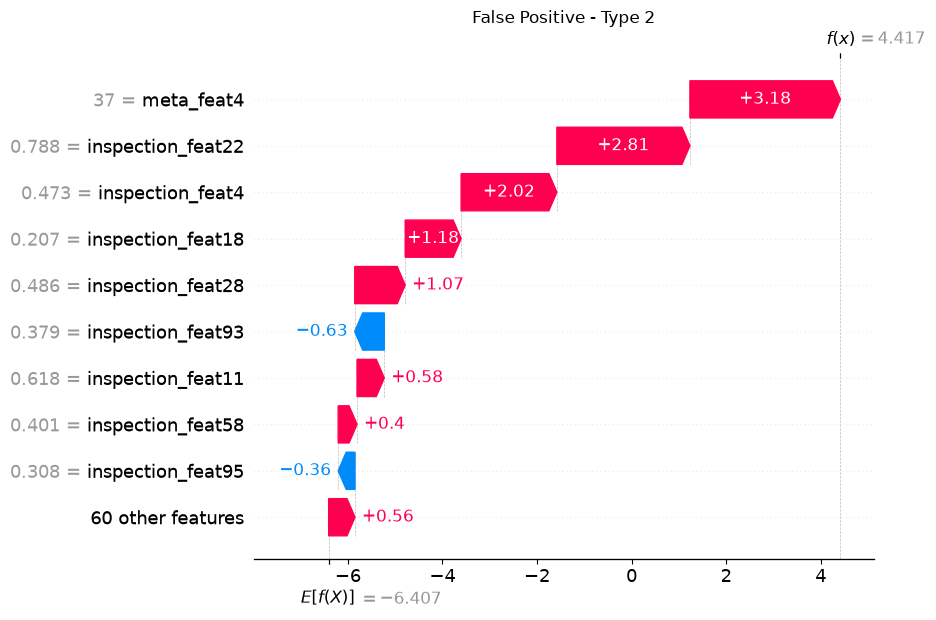


[ Inspection Type: 3 ]
- Test Samples: 30591
- Positive Samples: 603



>>> Global Summary Plot (Bar) for Type 3


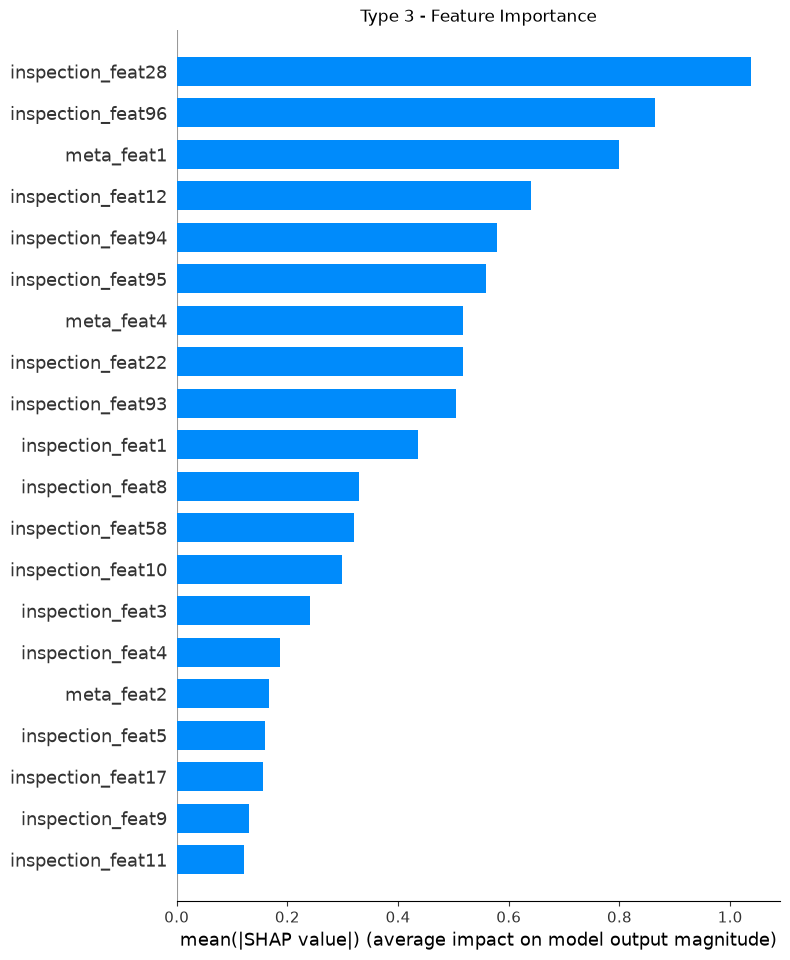


>>> Global Summary Plot (Beeswarm) for Type 3


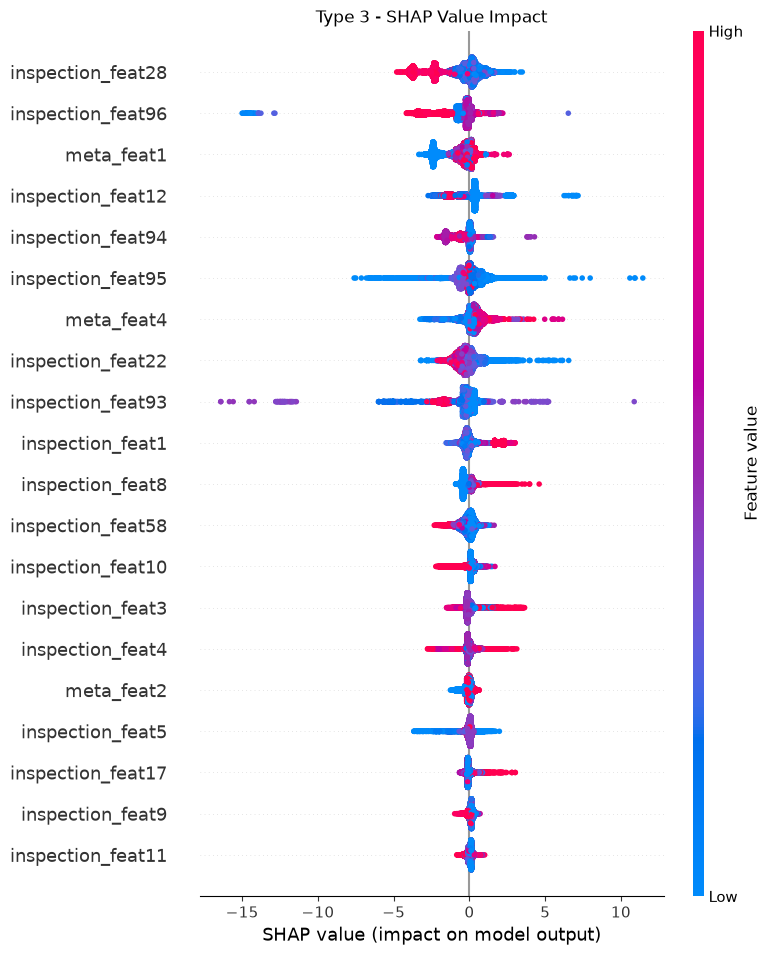


>>> Local Waterfall Plot for True Positive (Index 24862, Prob: 1.0000)


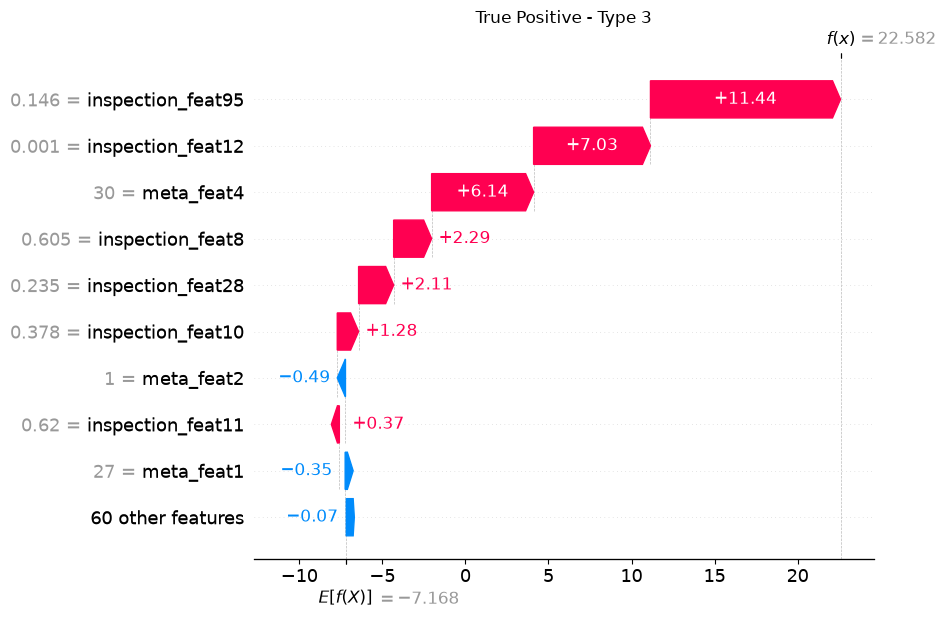


>>> Local Waterfall Plot for False Negative (Index 29111, Prob: 0.0000)


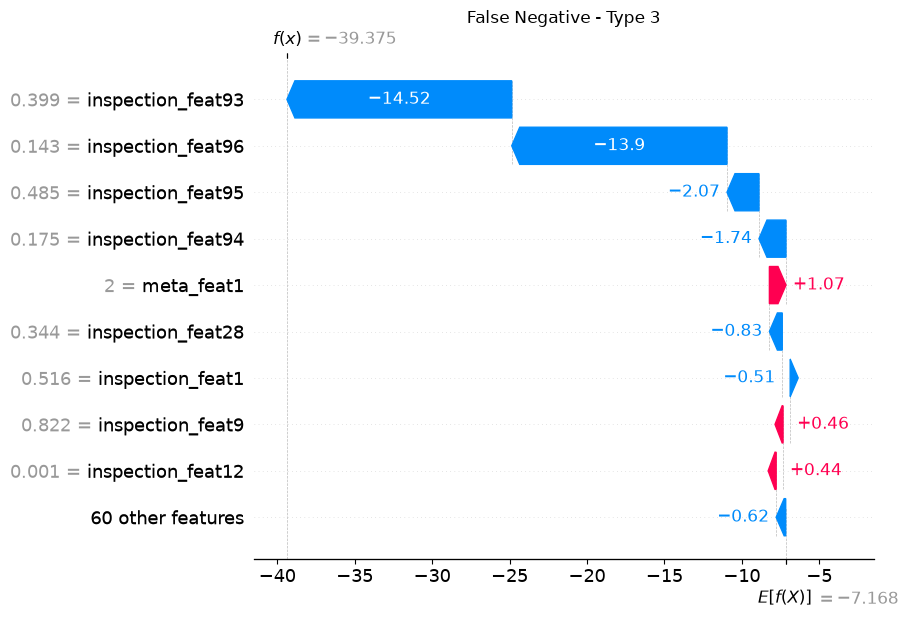


>>> Local Waterfall Plot for False Positive (Index 15614, Prob: 1.0000)


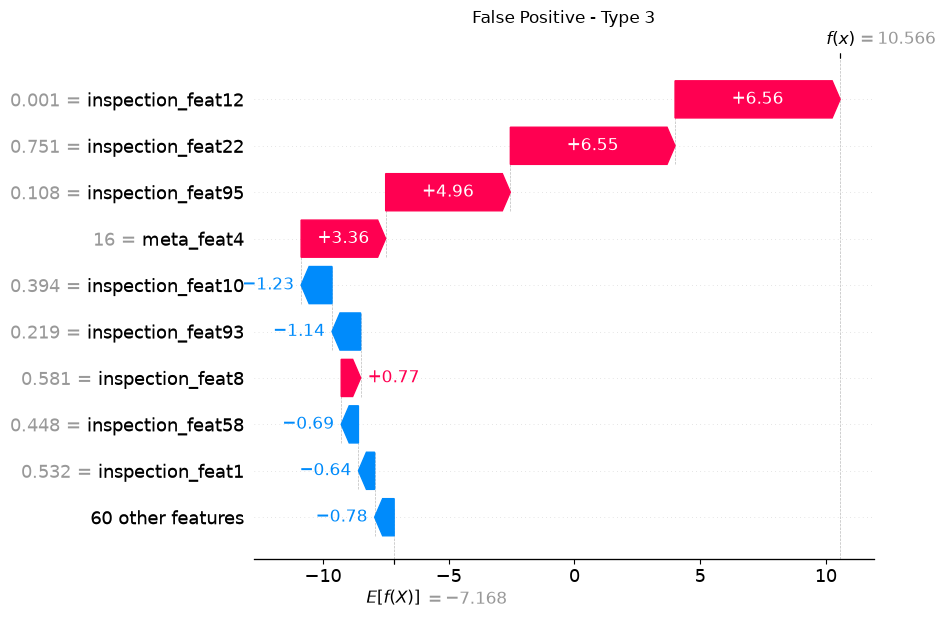


[ Inspection Type: 4 ]
- Test Samples: 756
- Positive Samples: 26

>>> Global Summary Plot (Bar) for Type 4


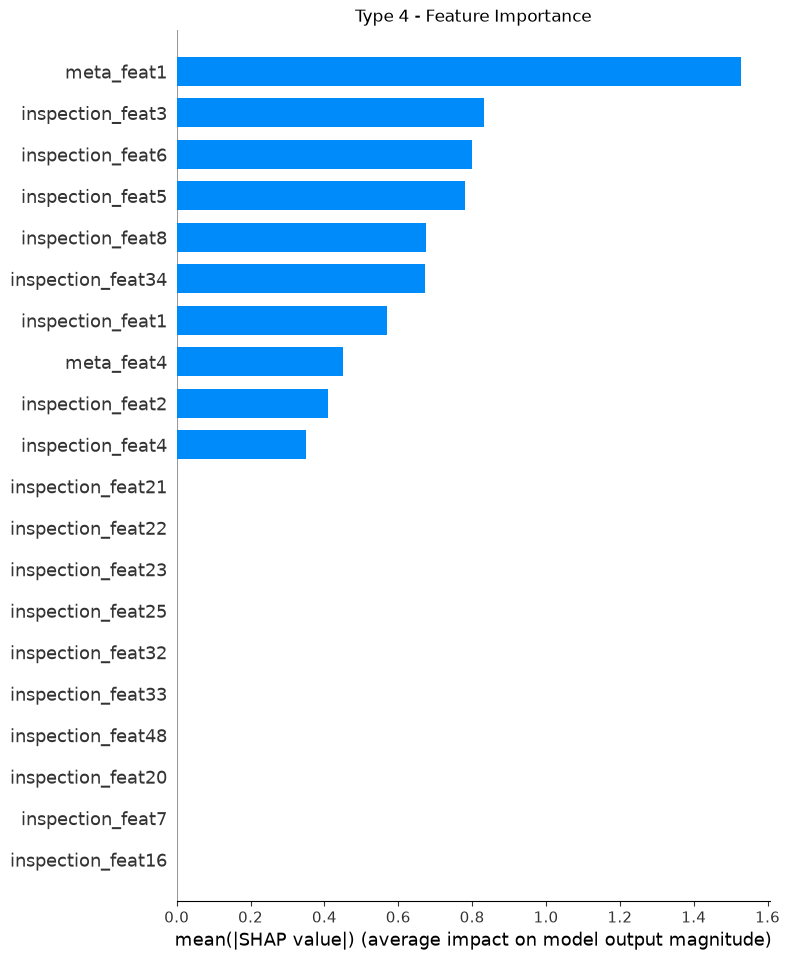


>>> Global Summary Plot (Beeswarm) for Type 4


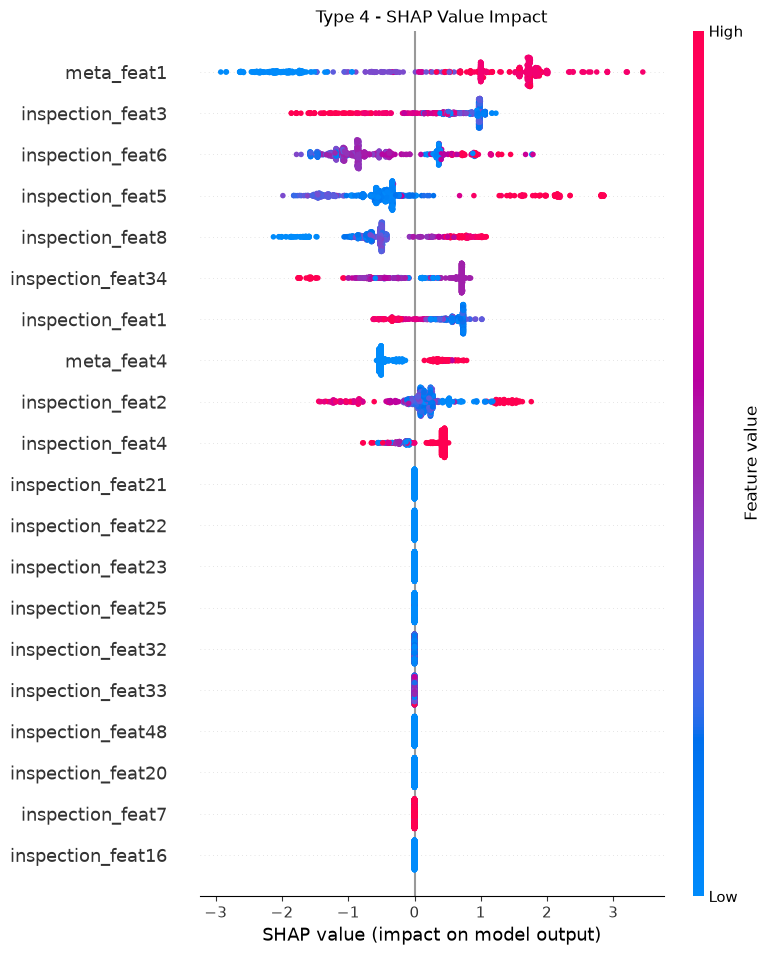


>>> Local Waterfall Plot for False Negative (Index 730, Prob: 0.0000)


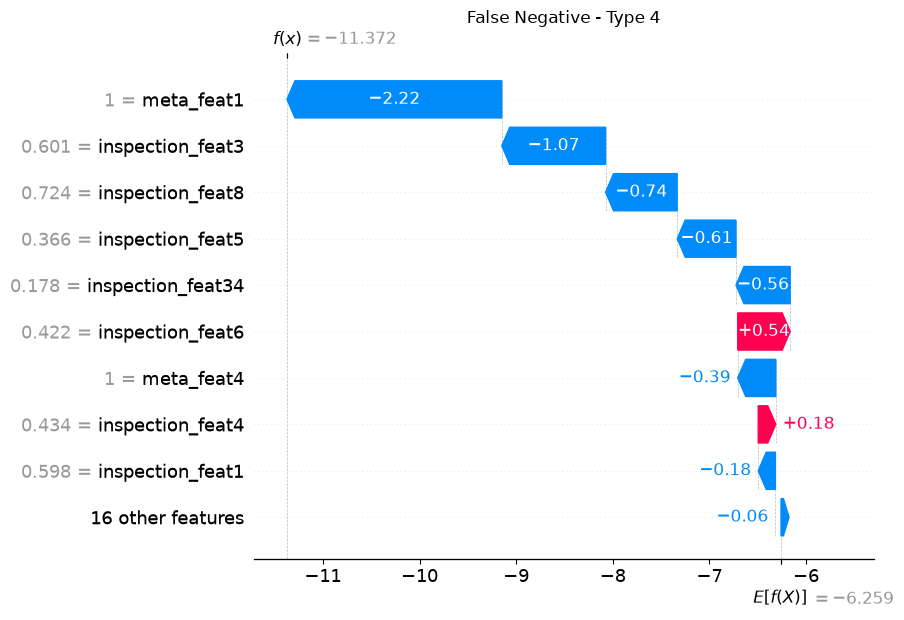


>>> Local Waterfall Plot for False Positive (Index 59, Prob: 0.8608)


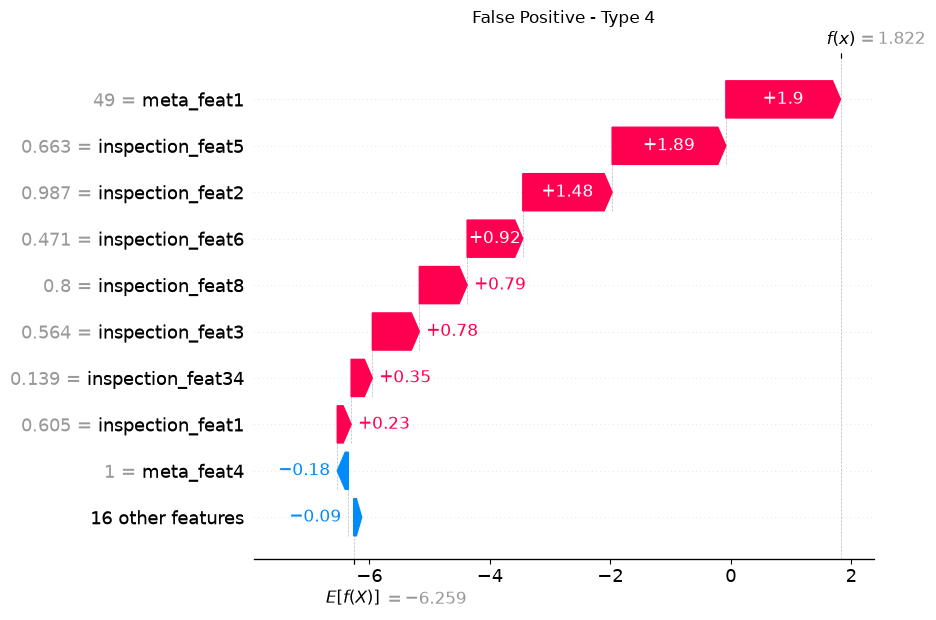

In [3]:
for inspection_type in inspection_types:
    print("="*60)
    print(f"\n[ Inspection Type: {inspection_type} ]")
    
    # 1) 해당 타입의 모델 및 특성, 데이터 로드
    model = models_by_type[inspection_type]
    features = feature_columns_by_type[inspection_type]
    
    type_test_df = test_df[test_df[TYPE_COLUMN] == inspection_type]
    if len(type_test_df) == 0:
        print("해당 타입의 Test 데이터가 없습니다. Skip.")
        continue
        
    X_test = type_test_df[features]
    y_test = type_test_df[TARGET].values
    
    # 예측 수행
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= decision_threshold).astype(int)
    
    print(f"- Test Samples: {len(X_test)}")
    print(f"- Positive Samples: {y_test.sum()}")
    
    # 2) TreeExplainer 초기화 및 SHAP 값 계산
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    # 3) Global Interpretability: Summary Plots
    print(f"\n>>> Global Summary Plot (Bar) for Type {inspection_type}")
    plt.figure()
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title(f"Type {inspection_type} - Feature Importance")
    plt.show()
    
    print(f"\n>>> Global Summary Plot (Beeswarm) for Type {inspection_type}")
    plt.figure()
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f"Type {inspection_type} - SHAP Value Impact")
    plt.show()
    
    # 4) Local Interpretability: 특정 인스턴스 분석 (TP, FN, FP)
    tp_indices = np.where((y_test == 1) & (predictions == 1))[0]
    fn_indices = np.where((y_test == 1) & (predictions == 0))[0]
    fp_indices = np.where((y_test == 0) & (predictions == 1))[0]
    
    if len(tp_indices) > 0:
        tp_idx = tp_indices[np.argmax(probabilities[tp_indices])]
        print(f"\n>>> Local Waterfall Plot for True Positive (Index {tp_idx}, Prob: {probabilities[tp_idx]:.4f})")
        exp_tp = shap.Explanation(values=shap_values[tp_idx,:], 
                               base_values=explainer.expected_value, 
                               data=X_test.iloc[tp_idx,:].values, 
                               feature_names=X_test.columns)
        plt.figure()
        shap.waterfall_plot(exp_tp, show=False)
        plt.title(f"True Positive - Type {inspection_type}")
        plt.show()
        
    if len(fn_indices) > 0:
        fn_idx = fn_indices[np.argmin(probabilities[fn_indices])]
        print(f"\n>>> Local Waterfall Plot for False Negative (Index {fn_idx}, Prob: {probabilities[fn_idx]:.4f})")
        exp_fn = shap.Explanation(values=shap_values[fn_idx,:], 
                               base_values=explainer.expected_value, 
                               data=X_test.iloc[fn_idx,:].values, 
                               feature_names=X_test.columns)
        plt.figure()
        shap.waterfall_plot(exp_fn, show=False)
        plt.title(f"False Negative - Type {inspection_type}")
        plt.show()
        
    if len(fp_indices) > 0:
        fp_idx = fp_indices[np.argmax(probabilities[fp_indices])]
        print(f"\n>>> Local Waterfall Plot for False Positive (Index {fp_idx}, Prob: {probabilities[fp_idx]:.4f})")
        exp_fp = shap.Explanation(values=shap_values[fp_idx,:], 
                               base_values=explainer.expected_value, 
                               data=X_test.iloc[fp_idx,:].values, 
                               feature_names=X_test.columns)
        plt.figure()
        shap.waterfall_plot(exp_fp, show=False)
        plt.title(f"False Positive - Type {inspection_type}")
        plt.show()
    print("="*60)
